In [3]:
!pip install ucimlrepo --break-system-packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from ucimlrepo import fetch_ucirepo

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import io
import urllib.request
import scipy.io
mat_data = scipy.io.loadmat('shuttle.mat')
#data from 
X = mat_data['X']
y = mat_data['y'].ravel()
print("--- Success! ---")
print(f"Features shape (X): {X.shape}")
print(f"Labels shape (y): {y.shape}")

--- Success! ---
Features shape (X): (49097, 9)
Labels shape (y): (49097,)


In [5]:
feature_columns = [f'feature_{i+1}' for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_columns)

In [6]:
X_df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
0,50,21,77,0,28,0,27,48,22
1,53,0,82,0,52,-5,29,30,2
2,37,0,76,0,28,18,40,48,8
3,37,0,79,0,34,-26,43,46,2
4,85,0,88,-4,6,1,3,83,80
...,...,...,...,...,...,...,...,...,...
49092,39,-2,80,-4,38,0,41,41,0
49093,43,0,81,1,42,-9,37,39,2
49094,49,0,87,0,46,-12,38,41,2
49095,80,0,84,0,-36,-29,4,120,116


In [7]:
X_df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
count,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000,49097.000000
mean,46.932399,-0.063955,85.123124,0.213231,36.871784,2.160030,38.200725,48.288592,10.261930
std,12.875159,84.674481,8.877517,37.579171,19.963113,218.324964,13.446306,20.572064,23.751024
min,27.000000,-4821.000000,21.000000,-3939.000000,-188.000000,-26739.000000,-48.000000,-353.000000,-356.000000
25%,37.000000,0.000000,79.000000,0.000000,30.000000,-4.000000,33.000000,35.000000,0.000000
50%,44.000000,0.000000,83.000000,0.000000,42.000000,0.000000,39.000000,41.000000,2.000000
75%,50.000000,0.000000,88.000000,0.000000,46.000000,5.000000,43.000000,55.000000,6.000000
max,126.000000,5075.000000,149.000000,3830.000000,436.000000,15164.000000,105.000000,270.000000,266.000000


In [8]:
print(X_df.isna().sum())

feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
feature_6    0
feature_7    0
feature_8    0
feature_9    0
dtype: int64


In [9]:
print(X_df[X_df.isna().any(axis=1)])

Empty DataFrame
Columns: [feature_1, feature_2, feature_3, feature_4, feature_5, feature_6, feature_7, feature_8, feature_9]
Index: []


In [10]:
nan_rows = X_df[X_df.isna().any(axis=1)]
print(nan_rows)
#this shows we have not any rows with NaN so replacement needed

Empty DataFrame
Columns: [feature_1, feature_2, feature_3, feature_4, feature_5, feature_6, feature_7, feature_8, feature_9]
Index: []


In [11]:
print(X_df.shape)
X_df.head()

(49097, 9)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
0,50,21,77,0,28,0,27,48,22
1,53,0,82,0,52,-5,29,30,2
2,37,0,76,0,28,18,40,48,8
3,37,0,79,0,34,-26,43,46,2
4,85,0,88,-4,6,1,3,83,80


In [12]:
n_estimators=100
contamination=0.075
sample_size=256


In [13]:
iso_forest=IsolationForest(n_estimators=n_estimators,contamination=contamination,max_samples=256,random_state=42)
iso_forest.fit(X_df)

,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",256
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.075
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [14]:
data=X_df

In [15]:

X_test_features = X_df

data = X_df.copy()

data['anomaly_score'] = iso_forest.decision_function(X_test_features)
data['anomaly'] = iso_forest.predict(X_test_features)

print(data['anomaly'].value_counts())

anomaly
 1    45414
-1     3683
Name: count, dtype: int64


In [16]:
data[data['anomaly']==1].value_counts()

feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  feature_7  feature_8  feature_9  anomaly_score  anomaly
50          21        77          0         28          0         27         48         22         0.073395       1          1
53          0         82          0         52         -5         29         30         2          0.161392       1          1
37          0         76          0         28          18        40         48         8          0.167454       1          1
                      79          0         34         -26        43         46         2          0.164228       1          1
55         -1         95         -3         54         -4         40         41         2          0.111741       1          1
                                                                                                                            ..
38          2         79          0         38          18        42         41         0          0.172478       1 

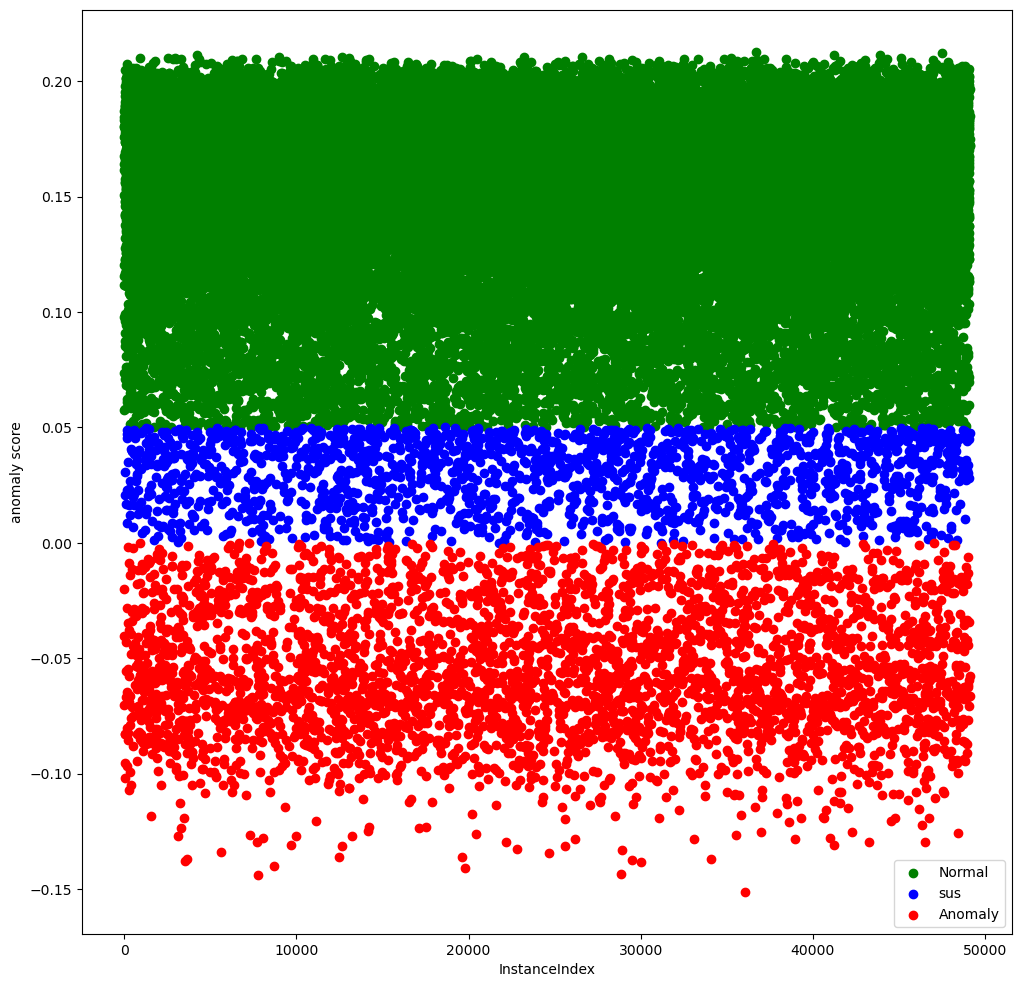

In [17]:
plt.figure(figsize=(12,12))
anomalies = data[data['anomaly_score'] < 0.0]

# Suspicious: Borderline positive scores close to the cutoff threshold
sus = data[(data['anomaly_score'] >= 0.0) & (data['anomaly_score'] <= 0.05)]
# Normal: Securely positive scores
normal = data[data['anomaly_score'] > 0.05]
plt.scatter(normal.index,normal['anomaly_score'],label='Normal',color='green')
plt.scatter(sus.index,sus['anomaly_score'],label='sus',color='blue')
plt.scatter(anomalies.index,anomalies['anomaly_score'],label='Anomaly',color='red')
plt.xlabel("InstanceIndex")
plt.ylabel("anomaly score")
plt.legend()
plt.show()

In [21]:
data.columns

Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'feature_9', 'anomaly_score',
       'anomaly'],
      dtype='str')

In [22]:
data['anomaly_score'].min()

-0.06453682866512256

In [19]:
import numpy as np
map_predictions=np.where(data['anomaly']==-1,1,0)

In [20]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
print("Classification Report")
print(classification_report(y,map_predictions,target_names=['Normal(0)','Anomaly(1)']))

Classification Report
              precision    recall  f1-score   support

   Normal(0)       1.00      0.99      1.00     45586
  Anomaly(1)       0.93      0.98      0.96      3511

    accuracy                           0.99     49097
   macro avg       0.97      0.99      0.98     49097
weighted avg       0.99      0.99      0.99     49097



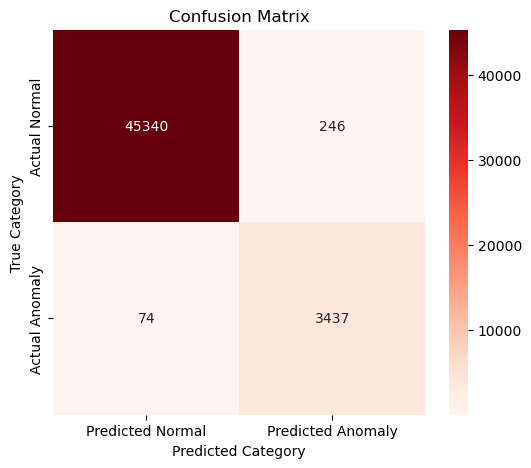

In [21]:
cm=confusion_matrix(y,map_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=['Predicted Normal','Predicted Anomaly'],yticklabels=['Actual Normal','Actual Anomaly'])
plt.title("Confusion Matrix")
plt.ylabel("True Category")
plt.xlabel("Predicted Category")
plt.show()

ROC - AUC curve auc value 0.9975


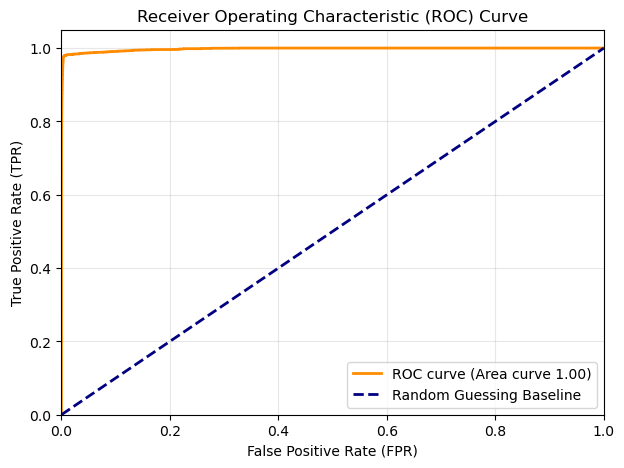

In [22]:
from sklearn.metrics import roc_auc_score,roc_curve
scores=iso_forest.decision_function(X_df)
inverted_scores=-scores
auc_val=roc_auc_score(y,inverted_scores)
print(f'ROC - AUC curve auc value {auc_val:.4f}')
fpr,tpr,thresholds=roc_curve(y,inverted_scores)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'ROC curve (Area curve {auc_val:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--',label='Random Guessing Baseline')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
tp=np.sum((y==1) & (map_predictions==1))
fp=np.sum((y==0) & (map_predictions==1))
tn=np.sum((y==0) & (map_predictions==0))
fn=np.sum((y==1) & (map_predictions==0))
precision=tp/(tp+fp)
recall=tp/(tp+fn)
f1_score=2*(precision*recall)/(precision+recall)

In [24]:
print(f'Precision is : {precision:.4f}')
print(f'Recall is : {recall:.4f}')
print(f'F1_score is : {f1_score:.4}')


Precision is : 0.9332
Recall is : 0.9789
F1_score is : 0.9555
